# 07 · Reducir errores: sacar la clase F y calibrar los umbrales

**De dónde sale esto.** El análisis de errores de la v2 en INCART mostró dos problemas:

| Tipo de error | Cantidad | % |
|---|---|---|
| V→S (confunde el tipo de latido anormal) | 1 472 | 23 % |
| N→V (falsa alarma) | 1 436 | 22 % |
| N→S (falsa alarma) | 1 295 | 20 % |
| V→N (no detecta un ventricular, RISK-01) | 1 006 | 16 % |
| Errores que involucran F | 870 | 14 % |

- **El modelo sobre-predice las clases raras:** marca S 2.3 veces más de lo que existe y F 4 veces.
- **La clase F no funciona en ningún conjunto** (+P ≤ 0.09): se aprende de un solo paciente.

Se prueban las dos correcciones más baratas: **sacar F del alcance** y **calibrar el umbral de
decisión por clase** (multiplicar cada probabilidad por un peso antes del `argmax`).

**Decidido antes de correr nada:**

- **Variantes:** A) la v2 actual sin poder emitir F · B) reentrenar con 3 clases ·
  C) B con umbrales que maximizan el F1 macro · D) B con umbrales sujetos a un **piso de
  sensibilidad para V**, porque el error más grave es no detectar un latido ventricular.
- **Mismos latidos y mismos folds** para todas (DS1 sin los 414 latidos F).
- **Calibración con validación anidada:** los umbrales se ajustan con una validación interna
  dentro del fold de entrenamiento, nunca con el fold que se mide.
- **Criterio:** F1 macro de 3 clases, reportando siempre cuántos latidos V quedan sin detectar.
- **INCART no se toca:** sigue congelada como validación externa.

> Proyecto educativo y de investigación. No es un dispositivo médico.

## 0. Una trampa que apareció en el camino: los folds se movían

La primera corrida de este experimento decía que sacar F **empeoraba** mucho el resultado. Era
falso, y la causa vale la pena documentarla: `GroupKFold` arma los folds equilibrando la **cantidad
de latidos**, así que al quitar los 414 latidos F cambió el reparto de pacientes.

In [1]:
import numpy as np

from ecg import config
from ecg.segment import load_split
from ecg.train import patient_folds

ds1 = load_split("ds1")
keep = ds1["y"] != "F"

def reparto(groups, **kw):
    mapa = {}
    for k, (_, va) in enumerate(patient_folds(groups, **kw)):
        for r in np.unique(groups[va]):
            mapa[int(r)] = k
    return mapa

con_f = reparto(ds1["record"])
sin_f = reparto(ds1["record"][keep])
print("registros que cambian de fold al quitar los latidos F:",
      {r: (con_f[r], sin_f[r]) for r in con_f if con_f[r] != sin_f[r]})
congelado = reparto(ds1["record"][keep], fold_map=config.DS1_FOLD_MAP)
print("con el mapa congelado (config.DS1_FOLD_MAP) coinciden:", congelado == con_f)

registros que cambian de fold al quitar los latidos F: {101: (1, 2), 230: (1, 3), 201: (2, 3), 108: (3, 2), 114: (3, 1), 208: (3, 4), 220: (3, 1), 124: (4, 3), 205: (4, 3)}
con el mapa congelado (config.DS1_FOLD_MAP) coinciden: True


**Conclusión:** 9 de 22 registros cambiaban de fold, así que la comparación medía dos cosas a la
vez. Por eso ahora el reparto de pacientes está **congelado** en `config.DS1_FOLD_MAP` y todos los
experimentos lo usan. Es la misma idea que atraviesa el proyecto: si la partición de pacientes
cambia, las métricas no son comparables.

## 1. Las cuatro variantes

In [2]:
import pandas as pd

from ecg.calibrate import apply_weights, tune_decision_weights
from ecg.evaluate import confusion, per_class_metrics, plot_confusion, summary
from ecg.features import build_features
from ecg.models.baseline import BaselineClassifier
from ecg.train import BASELINE_V2_CHOICE, BASELINE_V3_CHOICE, CLASSES_V3, cross_validate

pd.set_option("display.precision", 3)
X, F = ds1["X"][keep], ds1["F"][keep]
y, groups = ds1["y"][keep], ds1["record"][keep]
folds = patient_folds(groups, fold_map=config.DS1_FOLD_MAP)
print(f"{len(y)} latidos ({int((~keep).sum())} F excluidos) de {len(np.unique(groups))} pacientes")

50555 latidos (414 F excluidos) de 22 pacientes


In [3]:
# A · la v2 tal cual es: 4 clases, entrenada con TODOS los latidos de DS1 (incluidos los F).
# Solo se mide sobre los latidos que no son F y se le restringe la salida a N/S/V.
Z2, _ = build_features(ds1["X"], ds1["F"], BASELINE_V2_CHOICE["feature_set"],
                       records=ds1["record"])
cv_a = cross_validate(
    lambda: BaselineClassifier(
        kind=BASELINE_V2_CHOICE["kind"], params=BASELINE_V2_CHOICE["params"],
        feature_set=BASELINE_V2_CHOICE["feature_set"],
        weight_power=BASELINE_V2_CHOICE["weight_power"]),
    Z2, ds1["y"], ds1["record"], fold_map=config.DS1_FOLD_MAP)
pred_a = np.asarray(CLASSES_V3)[cv_a["proba"][keep][:, :3].argmax(axis=1)]
pred_a_4 = np.asarray(config.CLASSES)[cv_a["proba"][keep].argmax(axis=1)]
print("latidos que no son F pero la v2 llama F:", int((pred_a_4 == "F").sum()),
      f"({int(((pred_a_4 == 'F') & (y == 'N')).sum())} de ellos son N)")

latidos que no son F pero la v2 llama F: 564 (545 de ellos son N)


In [4]:
# B, C y D · un solo entrenamiento anidado; después se prueban los objetivos de calibración
Z3, _ = build_features(X, F, BASELINE_V3_CHOICE["feature_set"], records=groups)

def make_v3():
    c = BASELINE_V3_CHOICE
    return BaselineClassifier(kind=c["kind"], params=c["params"], feature_set=c["feature_set"],
                              weight_power=c["weight_power"], classes=list(CLASSES_V3))

proba = np.zeros((len(y), 3), dtype=np.float32)
interno = []
for tr, va in folds:
    ip = np.zeros((len(tr), 3), dtype=np.float32)
    for itr, iva in patient_folds(groups[tr], 4):       # validación interna para calibrar
        ip[iva] = make_v3().fit(Z3[tr][itr], y[tr][itr]).predict_proba(Z3[tr][iva])
    interno.append((tr, va, ip))
    proba[va] = make_v3().fit(Z3[tr], y[tr]).predict_proba(Z3[va])   # modelo del fold externo

In [5]:
OBJETIVOS = {
    "B · 3 clases, sin calibrar": None,
    "C · calibrado (F1 macro libre)": {},
    "D1 · calibrado, piso Se de V ≥ 0.90": {"V": 0.90},
    "D2 · calibrado, piso Se de V ≥ 0.95": {"V": 0.95},
}
predicciones = {"A · v2 (4 clases), salida restringida": pred_a}
pesos = {}
for nombre, piso in OBJETIVOS.items():
    pred = np.empty(len(y), dtype="<U1")
    ws = []
    for tr, va, ip in interno:
        w = {} if piso is None else tune_decision_weights(
            ip, y[tr], CLASSES_V3, min_sensitivity=piso or None)
        ws.append({k: round(float(v), 3) for k, v in w.items()} if w else "sin pesos")
        pred[va] = apply_weights(proba[va], w, CLASSES_V3)
    predicciones[nombre] = pred
    pesos[nombre] = ws

## 2. Comparación

In [6]:
filas = {}
for nombre, pred in predicciones.items():
    s = summary(y, pred, CLASSES_V3)
    filas[nombre] = {
        **{k: v for k, v in s.items() if v is not None},
        "V→N (RISK-01)": int(((y == "V") & (pred == "N")).sum()),
        "falsas alarmas sobre N": int(((y == "N") & (pred != "N")).sum()),
        "errores totales": int((y != pred).sum()),
    }
tabla = pd.DataFrame(filas).T
tabla[["macro_f1", "N_F1", "S_Se", "S_+P", "S_F1", "V_Se", "V_+P", "V_F1",
       "V→N (RISK-01)", "falsas alarmas sobre N", "errores totales"]].round(3)

,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,V→N (RISK-01),falsas alarmas sobre N,errores totales
"A · v2 (4 clases), salida restringida",0.644,0.945,0.370,0.363,0.367,0.911,0.468,0.619,311.0,4205.0,5137.0
"B · 3 clases, sin calibrar",0.649,0.946,0.376,0.382,0.379,0.914,0.471,0.622,298.0,4136.0,5050.0
C · calibrado (F1 macro libre),0.654,0.952,0.431,0.321,0.368,0.871,0.511,0.644,377.0,3632.0,4657.0
"D1 · calibrado, piso Se de V ≥ 0.90",0.621,0.941,0.300,0.338,0.318,0.917,0.450,0.603,298.0,4488.0,5462.0
"D2 · calibrado, piso Se de V ≥ 0.95",0.649,0.946,0.376,0.382,0.379,0.914,0.471,0.622,298.0,4136.0,5050.0


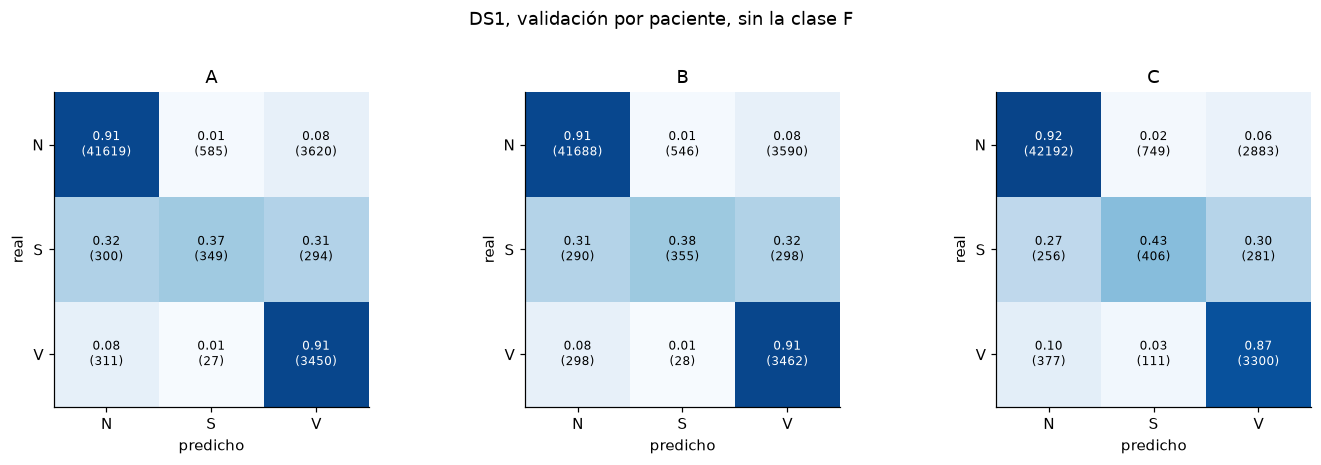

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
mostrar = ["A · v2 (4 clases), salida restringida", "B · 3 clases, sin calibrar",
           "C · calibrado (F1 macro libre)"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, nombre in zip(axes, mostrar):
    p = predicciones[nombre]
    plot_confusion(confusion(y, p, CLASSES_V3, normalize=True), ax, nombre.split(" · ")[0],
                   counts=confusion(y, p, CLASSES_V3))
fig.suptitle("DS1, validación por paciente, sin la clase F", y=1.03)
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / "figures" / "v3_calibration_confusion.png", bbox_inches="tight")

**Conclusiones:**

- **Sacar F ayuda poco en la métrica, pero mucho en el producto (A → B).** El F1 macro sube de
  0.644 a 0.649 y los errores bajan de 5 137 a 5 050: dentro del ruido. Lo importante es otra cosa:
  la v2 marcaba como F a **564 latidos que no lo eran** (545 de ellos normales) solo en DS1, y en
  DS2 esa cifra fue de **3 049 falsas F**. Un sistema que emite una clase con +P de 0.02 genera
  fatiga de alarmas (RISK-02) sin aportar nada.
- **La calibración presenta un intercambio real (B → C), no una mejora limpia.** Baja los errores
  totales un 7.8 % (5 050 → 4 657) y las falsas alarmas un 12 %, pero **deja 79 latidos
  ventriculares más sin detectar** (298 → 377, un 27 % más) y baja la Se de V de 0.914 a 0.871.
- En el análisis de riesgo, **no detectar un latido ventricular (RISK-01) es de severidad alta** y
  las falsas alarmas (RISK-02) son de severidad media. Con ese criterio, cambiar 79 ventriculares
  por 504 falsas alarmas menos **no es un buen negocio**, aunque el F1 macro suba 0.005.
- **Poner un piso de sensibilidad no rescata la calibración:** D1 (piso 0.90) termina peor en todo
  (F1 macro 0.621 y más falsas alarmas), y D2 (piso 0.95) no encuentra ninguna combinación que lo
  cumpla, así que se queda sin pesos y coincide exactamente con B.

## 3. ¿Por qué falla la calibración?

In [8]:
for nombre, ws in pesos.items():
    if ws[0] != "sin pesos":
        print(nombre)
        for k, w in enumerate(ws):
            print("   fold", k, w)

C · calibrado (F1 macro libre)
   fold 0 {'N': 1.0, 'S': 1.585, 'V': 1.585}
   fold 1 {'N': 1.0, 'S': 3.981, 'V': 0.1}
   fold 2 {'N': 1.0, 'S': 2.512, 'V': 0.1}
   fold 3 {'N': 1.0, 'S': 3.981, 'V': 0.251}
   fold 4 {'N': 1.0, 'S': 3.981, 'V': 0.1}
D1 · calibrado, piso Se de V ≥ 0.90
   fold 0 {'N': 1.0, 'S': 1.0, 'V': 1.0}
   fold 1 {'N': 1.0, 'S': 0.251, 'V': 3.981}
   fold 2 {'N': 1.0, 'S': 2.512, 'V': 3.981}
   fold 3 {'N': 1.0, 'S': 0.158, 'V': 3.981}
   fold 4 {'N': 1.0, 'S': 0.1, 'V': 1.0}
D2 · calibrado, piso Se de V ≥ 0.95
   fold 0 {'N': 1.0, 'S': 1.0, 'V': 1.0}
   fold 1 {'N': 1.0, 'S': 1.0, 'V': 1.0}
   fold 2 {'N': 1.0, 'S': 1.0, 'V': 1.0}
   fold 3 {'N': 1.0, 'S': 1.0, 'V': 1.0}
   fold 4 {'N': 1.0, 'S': 1.0, 'V': 1.0}


**Conclusión: los umbrales óptimos no son estables entre pacientes.**

Mirando los pesos elegidos en cada fold se ve el problema: el peso de S va de **1.585 a 3.981** y
el de V de **0.1 a 1.585** según qué pacientes toquen. No hay un punto de operación común: cada
grupo de pacientes pide uno distinto. Eso es exactamente lo que se espera cuando se ajusta ruido,
y explica por qué la ganancia en validación es de apenas 0.005.

En D1 pasa lo mismo al revés: para cumplir el piso de V, tres folds llevan el peso de V a 3.981 y
el de S a 0.1–0.25, y el resultado empeora.

**La calibración queda implementada pero desactivada** (`python -m ecg.train baseline-v3
--calibrate`). Si en el futuro el uso previsto prioriza reducir falsas alarmas sobre detectar
todos los ventriculares, el interruptor está y el intercambio está medido.

## 4. Qué queda como v3

In [9]:
import json

meta = json.loads((config.REPORTS_DIR / "baseline_v3_cv.json").read_text())
print("clases:", meta["classes"], "| fuera de alcance:", meta["fuera_de_alcance"])
print("calibrado:", meta["calibrado"], "| umbrales:", meta["decision_weights"])
pd.DataFrame({"v3 (CV DS1, 3 clases)": {k: meta["cv"][k] for k in
              ["macro_f1", "N_F1", "S_Se", "S_+P", "V_Se", "V_+P"]}}).round(3)

clases: ['N', 'S', 'V'] | fuera de alcance: ['F']
calibrado: False | umbrales: None


,"v3 (CV DS1, 3 clases)"
macro_f1,0.649
N_F1,0.946
S_Se,0.376
S_+P,0.382
V_Se,0.914
V_+P,0.471


## Resumen

**v3 = XGBoost con RR normalizado, 3 clases (N/S/V) y sin calibración.**
`python -m ecg.train baseline-v3` → `models/baseline_v3.joblib`.

| | A · v2 restringida | **B · v3** | C · calibrada |
|---|---|---|---|
| F1 macro (3 clases) | 0.644 | **0.649** | 0.654 |
| V no detectados (RISK-01) | 311 | **298** | 377 |
| Errores totales | 5 137 | 5 050 | 4 657 |

**Qué se logró con las ideas 1 y 2**

1. **Sacar F: sí.** Poca diferencia en la métrica, pero elimina una clase cuya +P nunca pasó de
   0.09 y que generaba miles de falsas alarmas. Además ordena el producto: F pasa a estar
   declarada fuera del alcance en el uso previsto.
2. **Calibrar umbrales: no.** La ganancia (0.005 de F1 macro) está dentro del ruido, los pesos
   óptimos son inestables entre folds y el precio es un 27 % más de latidos ventriculares no
   detectados. Se deja implementada y apagada, con el intercambio documentado.

**Lo que más se aprendió no fue sobre calibración, sino sobre método:** la primera corrida daba
que sacar F empeoraba todo, y era un artefacto de que `GroupKFold` movía 9 de 22 pacientes de fold
al filtrar latidos. Ahora el reparto está congelado en `config.DS1_FOLD_MAP` y hay una prueba que
lo verifica.

**Lo que sigue teniendo el mayor potencial** es la idea 3: describir la morfología **relativa al
latido dominante de cada paciente**, igual que `rr_norm` hizo con el ritmo. Los errores siguen
concentrados en pocos pacientes (5 explican más del 80 % de varios tipos de error), que es
justamente lo que esa idea ataca. La idea 4 (entrenar con DS1 + DS2, 44 pacientes en vez de 22)
también está pendiente.

Cualquiera de las dos se valida en DS1 y se confirma, **una sola vez**, en una base nueva:
INCART ya se usó para comparar v1 con v2 y conviene no gastarla otra vez; la candidata natural es
SVDB, que es rica en latidos supraventriculares.